In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image
import requests
import numpy as np
from io import BytesIO

In [2]:
# Filepaths for all CSVs and Color Data

weekly_totals_filepath = r"C:\Users\13012\OneDrive\Documents\vs-code-projects\ff_player_performance\data\claude_data\weekly_stats_2025.csv"
season_totals_filepath = r"C:\Users\13012\OneDrive\Documents\vs-code-projects\ff_player_performance\data\claude_data\season_totals_2025.csv"
nfl_teams_filepath = r"C:\Users\13012\OneDrive\Documents\vs-code-projects\ff_player_performance\data\nfl_teams.csv"
nfl_games_2025_filepath = r"C:\Users\13012\OneDrive\Documents\vs-code-projects\ff_player_performance\data\cleaned_data\games_2025.csv"

POSITION_COLORS = {
    "QB": "#3B82F6",   # Blue
    "RB": "#22C55E",   # Green
    "WR": "#F97316",   # Orange
    "TE": "#A855F7",   # Purple
    "K":  "#EAB308",   # Yellow
    "DST":"#EF4444",   # Red
}

In [3]:
# Load All Necessary Dataframes
weekly_df = pd.read_csv(weekly_totals_filepath)
season_df = pd.read_csv(season_totals_filepath)
nfl_teams_df = pd.read_csv(nfl_teams_filepath)
nfl_games_df = pd.read_csv(nfl_games_2025_filepath)

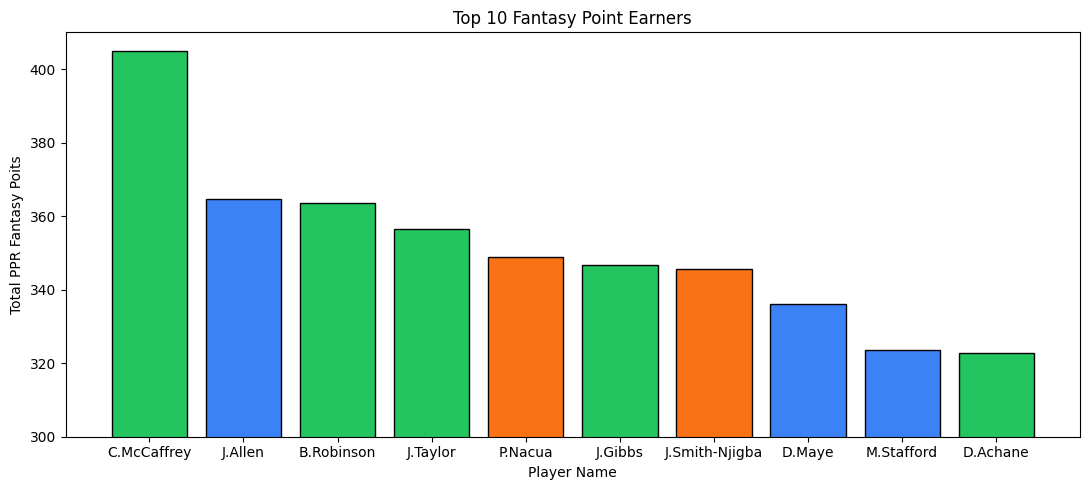

In [8]:
# Top 10 PPR Scores

top_10_ppr_scores = season_df.sort_values(by=["total_fantasy_ppr"], ascending=False)[:10]
colors = top_10_ppr_scores["position"].map(POSITION_COLORS)

fig = plt.figure(figsize=(11, 5), dpi=100, layout='tight')
ax = fig.add_subplot()

ax.bar(top_10_ppr_scores['player_name'], top_10_ppr_scores['total_fantasy_ppr'], color=colors, edgecolor='black')

ax.set_title('Top 10 Fantasy Point Earners')
ax.set_xlabel('Player Name')
ax.set_ylabel('Total PPR Fantasy Poits')
ax.set_ylim(300, 410)

plt.show()

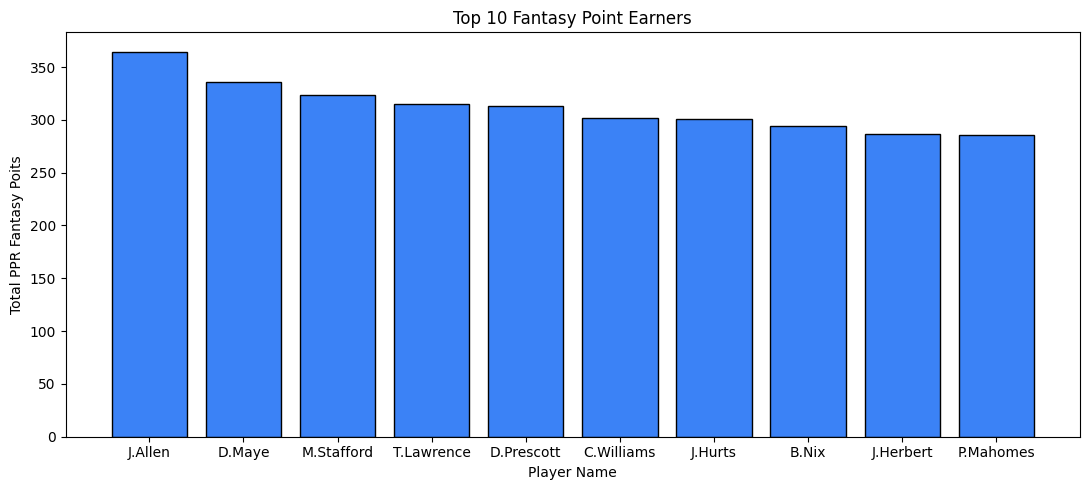

In [5]:
# Top 10 PPR Scores for Quarterbacks

top_10_ppr_scores = season_df[season_df['position'] == 'QB'].sort_values(by=["total_fantasy_ppr"], ascending=False)[:10]
colors = top_10_ppr_scores["position"].map(POSITION_COLORS)

fig = plt.figure(figsize=(11, 5), dpi=100, layout='tight')
ax = fig.add_subplot()

ax.bar(top_10_ppr_scores['player_name'], top_10_ppr_scores['total_fantasy_ppr'], color=colors, edgecolor='black')

ax.set_title('Top 10 Fantasy Point Earners')
ax.set_xlabel('Player Name')
ax.set_ylabel('Total PPR Fantasy Poits')
# ax.set_ylim(300, 410)

plt.show()

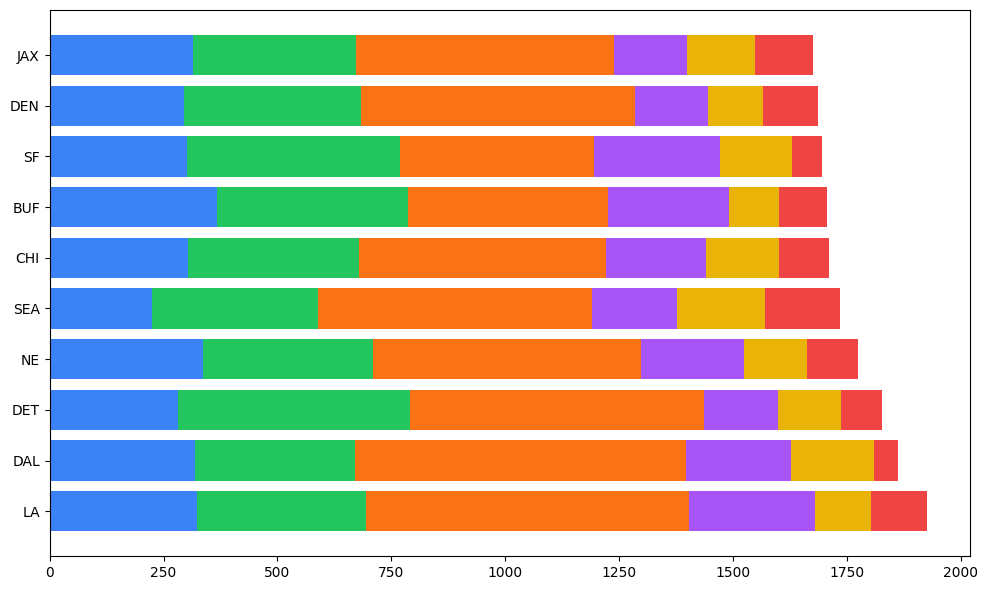

In [6]:
# 10 Highest Scoring NFL Teams

team_ppr = (
    season_df.groupby(["team", "position"])["total_fantasy_ppr"]
             .sum()
             .unstack(fill_value=0)
             .rename(columns=lambda x: f"total_fantasy_ppr_{x.lower()}")
)

# Add total team fantasy points
team_ppr["total_fantasy_ppr"] = team_ppr.sum(axis=1)

# Move team back to a column
team_ppr = team_ppr.reset_index()
top_10_teams = team_ppr.sort_values(by=['total_fantasy_ppr'], ascending=False)[:10]

team_fig = plt.figure(figsize=(10, 6), dpi=100, layout='tight')
team_ax = team_fig.add_subplot()

team_ax.barh(
    top_10_teams["team"], 
    top_10_teams["total_fantasy_ppr_qb"], 
    label="QB", 
    color=POSITION_COLORS["QB"]
)

team_ax.barh(
    top_10_teams["team"], 
    top_10_teams["total_fantasy_ppr_rb"],
    left=top_10_teams["total_fantasy_ppr_qb"], 
    label="RB", 
    color=POSITION_COLORS["RB"]
)

team_ax.barh(
    top_10_teams["team"], 
    top_10_teams["total_fantasy_ppr_wr"], 
    left=top_10_teams["total_fantasy_ppr_qb"] + top_10_teams["total_fantasy_ppr_rb"],
    label="WR", 
    color=POSITION_COLORS["WR"]
)

team_ax.barh(
    top_10_teams["team"], 
    top_10_teams["total_fantasy_ppr_te"], 
    left=top_10_teams["total_fantasy_ppr_qb"] + top_10_teams["total_fantasy_ppr_rb"] + top_10_teams["total_fantasy_ppr_wr"],
    label="TE", 
    color=POSITION_COLORS["TE"]
)

team_ax.barh(
    top_10_teams["team"], 
    top_10_teams["total_fantasy_ppr_k"],
    left=top_10_teams["total_fantasy_ppr_qb"] + top_10_teams["total_fantasy_ppr_rb"] + top_10_teams["total_fantasy_ppr_wr"] + top_10_teams["total_fantasy_ppr_te"],
    label="K", 
    color=POSITION_COLORS["K"]
)

team_ax.barh(
    top_10_teams["team"], 
    top_10_teams["total_fantasy_ppr_dst"],
    left=top_10_teams["total_fantasy_ppr_qb"] + top_10_teams["total_fantasy_ppr_rb"] + top_10_teams["total_fantasy_ppr_wr"] + top_10_teams["total_fantasy_ppr_te"] + top_10_teams["total_fantasy_ppr_k"],
    label="DST", 
    color=POSITION_COLORS["DST"]
)

plt.show()